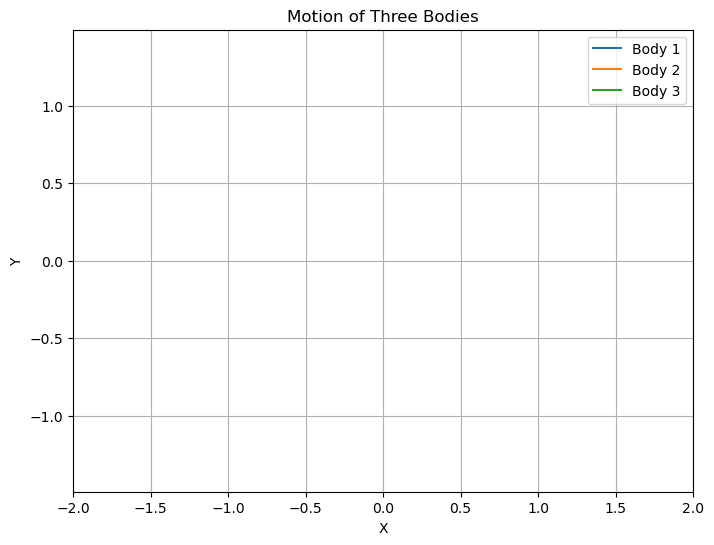

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Define parameters
G = 1.0  # Gravitational constant
m1 = 1.0  # Mass of body 1
m2 = 1.0  # Mass of body 2
m3 = 1.0  # Mass of body 3

# Define initial positions and velocities
r1_0 = np.array([1.0, 0.0])  # Initial position of body 1
r2_0 = np.array([-0.5, 0.5])  # Initial position of body 2
r3_0 = np.array([-0.5, -0.5])  # Initial position of body 3
v1_0 = np.array([0.0, 0.5])  # Initial velocity of body 1
v2_0 = np.array([0.5, 0.0])  # Initial velocity of body 2
v3_0 = np.array([0.0, -0.5])  # Initial velocity of body 3

# Define time parameters
dt = 0.01  # Time step
t_max = 10.0  # Maximum simulation time
n_steps = int(t_max / dt)  # Number of time steps

# Initialize arrays to store positions
r1 = np.zeros((n_steps, 2))
r2 = np.zeros((n_steps, 2))
r3 = np.zeros((n_steps, 2))

# Perform numerical integration (Euler's method)
for i in range(n_steps):
    # Calculate gravitational forces
    F1 = G * m1 * m2 * (r2_0 - r1_0) / np.linalg.norm(r2_0 - r1_0)**3 + \
         G * m1 * m3 * (r3_0 - r1_0) / np.linalg.norm(r3_0 - r1_0)**3
    F2 = G * m2 * m1 * (r1_0 - r2_0) / np.linalg.norm(r1_0 - r2_0)**3 + \
         G * m2 * m3 * (r3_0 - r2_0) / np.linalg.norm(r3_0 - r2_0)**3
    F3 = G * m3 * m1 * (r1_0 - r3_0) / np.linalg.norm(r1_0 - r3_0)**3 + \
         G * m3 * m2 * (r2_0 - r3_0) / np.linalg.norm(r2_0 - r3_0)**3
    
    # Update positions and velocities using Euler's method
    r1_0 += v1_0 * dt
    r2_0 += v2_0 * dt
    r3_0 += v3_0 * dt
    v1_0 += F1 / m1 * dt
    v2_0 += F2 / m2 * dt
    v3_0 += F3 / m3 * dt
    
    # Store positions
    r1[i] = r1_0
    r2[i] = r2_0
    r3[i] = r3_0

# Create animation
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Motion of Three Bodies')

line1, = ax.plot([], [], label='Body 1')
line2, = ax.plot([], [], label='Body 2')
line3, = ax.plot([], [], label='Body 3')

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    line3.set_data([], [])
    return line1, line2, line3

def update(frame):
    line1.set_data(r1[frame, 0], r1[frame, 1])
    line2.set_data(r2[frame, 0], r2[frame, 1])
    line3.set_data(r3[frame, 0], r3[frame, 1])
    return line1, line2, line3

ani = FuncAnimation(fig, update, frames=n_steps, init_func=init, blit=True)
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()



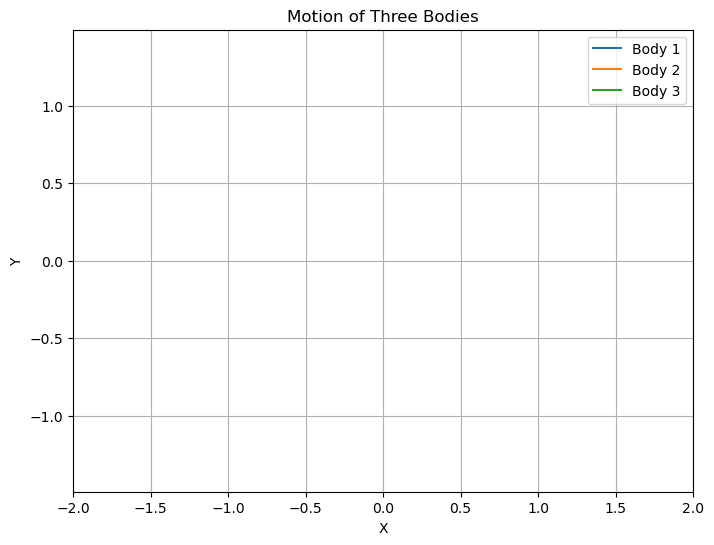

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Define parameters
G = 1.0  # Gravitational constant
m1 = 1.0  # Mass of body 1
m2 = 1.0  # Mass of body 2
m3 = 1.0  # Mass of body 3

# Define initial positions and velocities
r1 = np.array([1.0, 0.0])  # Initial position of body 1
r2 = np.array([-0.5, 0.5])  # Initial position of body 2
r3 = np.array([-0.5, -0.5])  # Initial position of body 3
v1 = np.array([0.0, 0.5])  # Initial velocity of body 1
v2 = np.array([0.5, 0.0])  # Initial velocity of body 2
v3 = np.array([0.0, -0.5])  # Initial velocity of body 3

# Define time parameters
dt = 0.01  # Time step
t_max = 10.0  # Maximum simulation time
n_steps = int(t_max / dt)  # Number of time steps

# Initialize arrays to store positions
positions = np.zeros((n_steps, 3, 2))
positions[0] = np.array([r1, r2, r3])

# Perform numerical integration (Euler's method)
for i in range(1, n_steps):
    # Calculate gravitational forces
    F1 = G * m1 * m2 * (r2 - r1) / np.linalg.norm(r2 - r1)**3 + \
         G * m1 * m3 * (r3 - r1) / np.linalg.norm(r3 - r1)**3
    F2 = G * m2 * m1 * (r1 - r2) / np.linalg.norm(r1 - r2)**3 + \
         G * m2 * m3 * (r3 - r2) / np.linalg.norm(r3 - r2)**3
    F3 = G * m3 * m1 * (r1 - r3) / np.linalg.norm(r1 - r3)**3 + \
         G * m3 * m2 * (r2 - r3) / np.linalg.norm(r2 - r3)**3
    
    # Update positions and velocities using Euler's method
    r1 += v1 * dt
    r2 += v2 * dt
    r3 += v3 * dt
    v1 += F1 / m1 * dt
    v2 += F2 / m2 * dt
    v3 += F3 / m3 * dt
    
    # Store positions
    positions[i] = np.array([r1, r2, r3])

# Create animation
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Motion of Three Bodies')

lines = [ax.plot([], [], label=f'Body {i+1}')[0] for i in range(3)]

def init():
    for line in lines:
        line.set_data([], [])
    return lines

def update(frame):
    for i, line in enumerate(lines):
        line.set_data(positions[frame, i, 0], positions[frame, i, 1])
    return lines

ani = FuncAnimation(fig, update, frames=n_steps, init_func=init, blit=True)
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


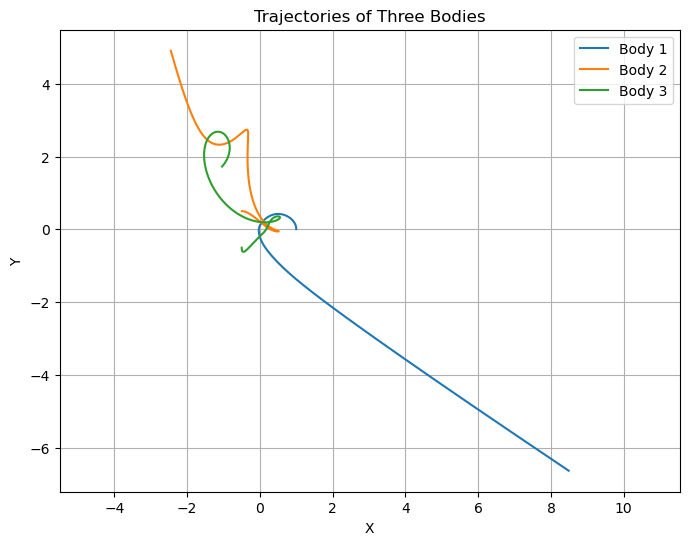

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
G = 1.0  # Gravitational constant
m1 = 1.0  # Mass of body 1
m2 = 1.0  # Mass of body 2
m3 = 1.0  # Mass of body 3

# Define initial positions and velocities
r1_0 = np.array([1.0, 0.0])  # Initial position of body 1
r2_0 = np.array([-0.5, 0.5])  # Initial position of body 2
r3_0 = np.array([-0.5, -0.5])  # Initial position of body 3
v1_0 = np.array([0.0, 0.5])  # Initial velocity of body 1
v2_0 = np.array([0.5, 0.0])  # Initial velocity of body 2
v3_0 = np.array([0.0, -0.5])  # Initial velocity of body 3

# Define time parameters
dt = 0.01  # Time step
t_max = 10.0  # Maximum simulation time
n_steps = int(t_max / dt)  # Number of time steps

# Initialize arrays to store positions
r1 = np.zeros((n_steps, 2))
r2 = np.zeros((n_steps, 2))
r3 = np.zeros((n_steps, 2))

# Perform numerical integration (Euler's method)
for i in range(n_steps):
    # Calculate gravitational forces
    F1 = G * m1 * m2 * (r2_0 - r1_0) / np.linalg.norm(r2_0 - r1_0)**3 + \
         G * m1 * m3 * (r3_0 - r1_0) / np.linalg.norm(r3_0 - r1_0)**3
    F2 = G * m2 * m1 * (r1_0 - r2_0) / np.linalg.norm(r1_0 - r2_0)**3 + \
         G * m2 * m3 * (r3_0 - r2_0) / np.linalg.norm(r3_0 - r2_0)**3
    F3 = G * m3 * m1 * (r1_0 - r3_0) / np.linalg.norm(r1_0 - r3_0)**3 + \
         G * m3 * m2 * (r2_0 - r3_0) / np.linalg.norm(r2_0 - r3_0)**3
    
    # Update positions and velocities using Euler's method
    r1_0 += v1_0 * dt
    r2_0 += v2_0 * dt
    r3_0 += v3_0 * dt
    v1_0 += F1 / m1 * dt
    v2_0 += F2 / m2 * dt
    v3_0 += F3 / m3 * dt
    
    # Store positions
    r1[i] = r1_0
    r2[i] = r2_0
    r3[i] = r3_0

# Plot trajectories
plt.figure(figsize=(8, 6))
plt.plot(r1[:, 0], r1[:, 1], label='Body 1')
plt.plot(r2[:, 0], r2[:, 1], label='Body 2')
plt.plot(r3[:, 0], r3[:, 1], label='Body 3')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Trajectories of Three Bodies')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

